# Ruse

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import time
import shutil
import pathlib
import tempfile
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
import matplot2tikz 
from helpers import *

sys.path.append(os.path.join(get_workspace_root(), './scripts'))
from merge_results import merge_run_results

## Default experiment configuration

In [3]:
default_config = {
    "timeout": datetime.timedelta(hours=1),
    "max_iterations": 6,
    "max_sequence_size": 3,
    "max_mutations": 3,
    "max_memory_usage": "100GiB",
    "workers_count": 64
}

## Helper functions

#### Some notebook helper functions

In [4]:
def display_df(s):
    if isinstance(s, pd.DataFrame):
        s = s.style
    
    s.set_properties(**{'text-align': 'left'})
    s.set_table_styles([dict(selector='th', props=[('text-align', 'left')])])
    
    html_table = s.to_html(justify='left', notebook=True, show_dimensions=True, index=False)

    scrollable_html = f"""
<div style="max-height: 300px; overflow: auto;">
    {html_table}
</div>
"""
    display(HTML(scrollable_html))

class StopExecution(Exception):
    def _render_traceback_(self):
        return []

#### Parse results

In [5]:
def sort_by_oop_and_side_effects_and_name(df: pd.DataFrame, inplace=False):
    oop_category_order = {
        "Full OOP": 0,
        "Primitive Objects": 1,
        "Primitive": 2,
    }

    side_effects_order = {
        "With Side Effects": 0,
        "Possibly With Side Effects": 1,
        "Without Side Effects": 2
    }

    def sort_func(col):
        if col.name == "oop_category":
            return col.apply(lambda x: oop_category_order[x])
        if col.name == "side_effects":
            return col.apply(lambda x: side_effects_order[x])
        if col.name == "name":
            return col

    return df.sort_values(by=["oop_category", "side_effects", "name"], key=sort_func, inplace=inplace)


def sort_by_found_time(df: pd.DataFrame):
    def sort_func(col):
        if col.name == "found":
            return col.apply(lambda x: 0 if pd.notna(x) else 1)
        if col.name == "total_time":
            return col

    df.sort_values(by=["found", "total_time"], key=sort_func, inplace=True)


def get_sy_info(path):
    with open(path, "r") as f:
        return json.load(f)


def create_tasks_dataframe(tasks, dry_run) -> pd.DataFrame:
    df = pd.DataFrame(tasks)
    df["name"] = df["path"].apply(lambda x: os.path.basename(x).split(".")[0])
    df["total_time"] = df["total_time"].apply(lambda x: pd.Timedelta(
        seconds=x["secs"], nanoseconds=x["nanos"]).total_seconds() if pd.notnull(x) else x).astype(dtype="float64")
    df["path"] = df["path"].apply(lambda x: os.path.relpath(
        os.path.abspath(x), get_workspace_root()))
    df.rename(columns={"total_statistics": "stats"}, inplace=True)

    if "category" in df.columns:
        df["oop_category"] = df["category"].apply(lambda x: x.split(":")[0])
        df["side_effects"] = df["category"].apply(lambda x: x.split(":")[1])
        df.pop("category")

    df = pd.json_normalize(df.to_dict(orient="records"))
    if not dry_run:
        if "found" in df.columns:
            df.pop("found")
        df.rename(columns={"found.found": "found"}, inplace=True)
        sort_by_found_time(df)

    df = df.convert_dtypes(infer_objects=True, convert_string=True,
                           convert_integer=False, convert_boolean=True)

    df['stats.iteration_count'] = df['iterations'].apply(lambda x: len(x))

    ordered_columns = ['name',
                       'total_time',
                       'found',
                       'error',
                       'found.has_side_effects',
                       'found.num_mutations',
                       'found.solution_size',
                       'found.solution_depth',
                       'path',
                       'source',
                       'category',
                       'oop_category',
                       'side_effects',
                       'opcode_count',
                       'max_vm_usage',
                       'stats.Evaluated',
                       'stats.BankSize',
                       'stats.FoundContextCount',
                       'stats.MaxMutatingOpcodes',
                       'stats.MaxDepth',
                       'stats.MaxSize',
                       'stats.iteration_count',
                       'string_literals',
                       'num_literals',
                       'iterations',
                       'start_context.graph_statistics',
                       'start_context.variables',]

    integer_columns = ['found.num_mutations', 'found.solution_size', 'found.solution_depth', 'opcode_count', 'stats.Evaluated',
                       'stats.BankSize', 'stats.FoundContextCount', 'stats.MaxMutatingOpcodes', 'stats.MaxDepth', 'stats.MaxSize',
                       'stats.iteration_count']
    
    for col in integer_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce', downcast='integer')

    ordered_columns = [col for col in ordered_columns if col in df.columns]
    df = df[ordered_columns]

    return df

def parse_run(run_data, dry_run):
    df = create_tasks_dataframe(run_data["tasks"], dry_run)

    df["expected"] = df["path"].apply(lambda x: get_sy_info(
        os.path.join(get_workspace_root(), x))["solution"]["expected"])
    df["examples_count"] = df["path"].apply(lambda x: len(
        get_sy_info(os.path.join(get_workspace_root(), x))["examples"]))
    df["var_count"] = df["path"].apply(lambda x: len(
        get_sy_info(os.path.join(get_workspace_root(), x))["variables"]))

    metadata = run_data["metadata"]
    metadata["tasks_count"] = len(df)
    metadata["total_time"] = datetime.timedelta(seconds=df["total_time"].sum())
    metadata["error_count"] = df["error"].notna().sum()

    return metadata, df

def parse_results(results_dir, dry_run):
    tasks = []
    metadata = []
    for file in os.listdir(results_dir):
        if file.endswith('.json'):
            with open(os.path.join(results_dir, file), 'r') as f:
                run_data = json.load(f)
            run_metadata, run_tasks = parse_run(run_data, dry_run)
            tasks.append(run_tasks)
            metadata.append(run_metadata)

    return metadata, pd.concat(tasks, ignore_index=True)

def group_tasks(tasks: pd.DataFrame):
    def parse_vm_usage(usage):
        units = {"B": 1, "KB": 10**3, "MB": 10**6, "GB": 10**9, "TB": 10**12}
        number, unit = [string.strip() for string in usage.split()]
        return int(float(number)*units[unit])


    def calc_max_vm_usage_mean(usage):
        return usage.apply(parse_vm_usage).mean()

    def calc_max_vm_usage_min(usage):
        return usage.apply(parse_vm_usage).min()

    def calc_max_vm_usage_max(usage):
        return usage.apply(parse_vm_usage).max()

    return tasks.groupby('name').agg(
        total_time = ('total_time', 'mean'),
        total_time_min = ('total_time', 'min'),
        total_time_max = ('total_time', 'max'),
        iteration_count = ('stats.iteration_count', 'first'),
        solved_count=('found', lambda x: x.notnull().sum()),
        found=('found', lambda x: set(x) if x.notnull().any() else None),
        expected=('expected', 'first'),
        solution_size_min=('found.solution_size', 'min'),
        solution_size_max=('found.solution_size', 'max'),
        bank_size=('stats.BankSize', 'mean'),
        bank_size_min=('stats.BankSize', 'min'),
        bank_size_max=('stats.BankSize', 'max'),
        found_context=('stats.FoundContextCount', 'mean'),
        found_context_min=('stats.FoundContextCount', 'min'),
        found_context_max=('stats.FoundContextCount', 'max'),
        iterations=('iterations', 'first'),
        oop_category=('oop_category', 'first'),
        path=('path', 'first'),
        examples_count=('examples_count', 'first'),
        var_count=('var_count', 'first'),
        max_vm_usage=('max_vm_usage', calc_max_vm_usage_mean),
        max_vm_usage_min=('max_vm_usage', calc_max_vm_usage_min),
        max_vm_usage_max=('max_vm_usage', calc_max_vm_usage_max),
        start_context=('start_context.graph_statistics', 'first'),
        start_context_variables=('start_context.variables', 'first'),
        opcode_count=('opcode_count', 'first')
    ).reset_index()
    

In [6]:
class TaskParserError(Exception):
    def __init__(self, errors):
        self.errors = errors

    def _render_traceback_(self):
        return []


def get_all_tasks(tasks):
    errors = []

    with tempfile.TemporaryDirectory() as temp_dir:
        results_dir = os.path.join(temp_dir, "results")
        log = os.path.join(temp_dir, "log.jsonl")

        run_ruse(tasks, results_dir, log_file=log, dry_run=True, in_background=False)
        _metadata, tasks = parse_run(merge_run_results(results_dir), dry_run=True)

        with open(log, "r") as f:
            for line in f:
                parsed = json.loads(line)
                if parsed["level"] == "ERROR":
                    pprint(parsed)
                    errors.append(parsed)
    if len(errors) > 0:
        raise TaskParserError(errors)

    return sort_by_oop_and_side_effects_and_name(tasks)

In [7]:
def save_tasks_latex_table(df: pd.DataFrame, filename: str, caption: str, label: str):

    columns = ["name", "side_effects", "examples_count", "var_count"]
    headers = ["Task", "Side Effects", "\#Examples", "\#Variables"]
    column_types = ["l", "c", "c", "c"]
    df = df[columns].copy()

    def side_effects_formatter(x):
        if x == "Without Side Effects":
            return "No"
        elif x == "With Side Effects":
            return "Yes"
        elif x == "Possibly With Side Effects":
            return "Possibly"
        raise ValueError(f"Unknown side effect: {x}")

    df["side_effects"] = df["side_effects"].apply(side_effects_formatter)
    df["name"] = df["name"].apply(lambda x: x.replace("_", "\\_"))

    latex = ""
    latex += f"\\begin{{longtable}}{{| l | c c c |}}\n"
    latex += f"\t\\caption{{{caption}. \label{{{label}}} }} \\\\\n\n"
    
    latex += '\t\\hline\n'
    latex += f'\t\\multicolumn{{{len(df.columns)}}}{{| c |}}{{Begin of Table}} \\\\\n'
    latex += '\t\\hline\n'
    latex += "\t" + " & ".join([f"\\textbf{{{h}}}" for h in headers])
    latex += " \\\\\n"
    latex += '\t\\hline\n'
    latex += '\t\\endfirsthead\n\n'

    latex += '\t\\hline\n'
    latex += f'\t\\multicolumn{{{len(df.columns)}}}{{| c |}}{{Continuation of Table \\ref{{{label}}}}} \\\\\n'
    latex += '\t\\hline\n'
    latex += "\t" + " & ".join([f"\\textbf{{{h}}}" for h in headers])
    latex += " \\\\\n"
    latex += '\t\\hline\n'
    latex += '\t\\endhead\n\n'

    latex += '\t\\hline\n'
    latex += '\t\\endfoot\n'
    latex += '\t\\hline\\hline\n'
    latex += '\t\\endlastfoot\n\n'

    for _, row in df.iterrows():
        latex += "\t" + " & ".join([f"{cell}" for cell in row])
        latex += " \\\\\n"
    latex += f"\\end{{longtable}}\n"
    with open(filename, "w") as f:
        f.write(latex)

def save_figure_as_latex(filename: str, **kwargs):
    tikz_plot = matplot2tikz.get_tikz_code(filepath=filename, **kwargs)
    latex = tikz_plot
    with open(filename, "w") as f:
        f.write(latex)

## Experiments

### Benchmarks

We divide the benchmarks into two categories:
* Tasks that use only primitive and built-in objects (Like Array and Set)
* Tasks that use custom User classes

In [8]:
tasks_paths = [
    os.path.join(get_workspace_root(), "tasks/benchmarks/fromFrangel"),
    os.path.join(get_workspace_root(), "tasks/benchmarks/fromSobeq"),
    os.path.join(get_workspace_root(), "tasks/benchmarks/new_ruse/simple"),
    os.path.join(get_workspace_root(), "tasks/benchmarks/new_ruse/full_oop"),
]

try:
    tasks = get_all_tasks(tasks_paths)
except Exception as e:
    if isinstance(e, TaskParserError):
        raise StopExecution
    else: 
        raise e

display_df(tasks[["name", "side_effects", "expected"]])

full_oop_tasks = tasks[tasks["oop_category"] == "Full OOP"]
primitive_tasks = tasks[tasks["oop_category"] != "Full OOP"]

../target/release/Ruse run -o /tmp/tmpl58h4azo/results -t 3600 --workers-count 64 --max-iterations 5 --max-mutations 3 --max-sequence-size 2 --max-task-mem 100GiB --log /tmp/tmpl58h4azo/log.jsonl --dry-run -b ../tasks/benchmarks/fromFrangel -b ../tasks/benchmarks/fromSobeq -b ../tasks/benchmarks/new_ruse/simple -b ../tasks/benchmarks/new_ruse/full_oop


,name,side_effects,expected
76,binary_search_tree_delete_two_children,With Side Effects,['node_to_delete.right.min_node().swap(node_to_delete).unlink_leaf()']
4,binary_search_tree_unlink_leaf,With Side Effects,['tree.right.unlink_leaf()']
93,mut_graph,With Side Effects,"['graph1.inc_value(); graph2.inc_value(); graph3.inc_value()', 'graph1.inc_value(); graph3.inc_value(); graph2.inc_value()', 'graph2.inc_value(); graph1.inc_value(); graph3.inc_value()', 'graph2.inc_value(); graph3.inc_value(); graph1.inc_value()', 'graph3.inc_value(); graph1.inc_value(); graph2.inc_value()', 'graph3.inc_value(); graph2.inc_value(); graph1.inc_value()']"
50,mut_graph_cycle,With Side Effects,"['graph1.inc_value(); graph2.inc_value(); graph3.inc_value()', 'graph1.inc_value(); graph3.inc_value(); graph2.inc_value()', 'graph2.inc_value(); graph1.inc_value(); graph3.inc_value()', 'graph2.inc_value(); graph3.inc_value(); graph1.inc_value()', 'graph3.inc_value(); graph1.inc_value(); graph2.inc_value()', 'graph3.inc_value(); graph2.inc_value(); graph1.inc_value()']"
84,mut_graph_one_way_connected,With Side Effects,['graph3.inc_value(); graph1.inc_value(); graph2.inc_value()']
90,set_subtree,With Side Effects,"['tree1.right = tree2; tree2.inc_value()', 'tree2.inc_value(); tree1.right = tree2;']"
42,binary_search_tree_get,Without Side Effects,['tree.right.value']
68,binary_search_tree_height,Without Side Effects,['tree.height']
36,binary_search_tree_valid,Without Side Effects,['tree.valid()']
27,elasticsearch_convert,Without Side Effects,"['DistanceUnit.convert(distance, from, to)']"


#### Tasks sources

In [9]:
ruse_source_tasks = tasks[tasks["path"].str.contains("new_ruse")]
frangel_source_tasks = tasks[tasks["path"].str.contains("fromFrangel")]
sobeq_source_tasks = tasks[tasks["path"].str.contains("fromSobeq")]

print(f"{len(ruse_source_tasks)} Ruse tasks")
print(f"{len(frangel_source_tasks)} FrAngel tasks")
print(f"{len(sobeq_source_tasks)} SoBEq tasks")
print(f"{len(tasks)} tasks")

pure_full_oop_tasks = tasks[(tasks["side_effects"] == "Without Side Effects") & (tasks["oop_category"] == "Full OOP")]
non_pure_full_oop_tasks = tasks[(tasks["side_effects"] != "Without Side Effects") & (tasks["oop_category"] == "Full OOP")]

pure_primitive_objects_tasks = tasks[(tasks["side_effects"] == "Without Side Effects") & (tasks["oop_category"] != "Full OOP")]
non_pure_primitive_objects_tasks = tasks[(tasks["side_effects"] != "Without Side Effects") & (tasks["oop_category"] != "Full OOP")]

print(len(pure_primitive_objects_tasks), len(non_pure_primitive_objects_tasks))
print(len(pure_full_oop_tasks), len(non_pure_full_oop_tasks))

18 Ruse tasks
15 FrAngel tasks
62 SoBEq tasks
95 tasks
36 33
20 6


#### Primitive tasks
We compare the primitive tasks against <span style="font-variant:small-caps;">SoBEq</span> and <span style="font-variant:small-caps;">FrAngel</span>

In [10]:
primitive_table = primitive_tasks.copy()

display_df(primitive_table[["name", "side_effects", "oop_category", "expected"]])
save_tasks_latex_table(primitive_table, "results/figures/primitive_tasks.tex", caption="Primitive and built-in objects tasks", label="primitive_tasks")

pure_primitive_solutions = primitive_table[primitive_table["side_effects"] == "Without Side Effects"]

print(f"{len(primitive_table)} primitive tasks")
print(f"{len(pure_primitive_solutions)} tasks expected solution is pure")
print(f"{len(primitive_table) - len(pure_primitive_solutions)} tasks expected solution can be solved with side effects")

,name,side_effects,oop_category,expected
88,ArrayCounter,With Side Effects,Primitive Objects,"['count[index]++, count', '(count[index]++, count)', 'count.slice(0,index).concat(count[index] + 1).concat(count.slice(index + 1))']"
31,ArrayCounter-mustmut,With Side Effects,Primitive Objects,['count[index]++; count']
1,ArraySwap,With Side Effects,Primitive Objects,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"
56,DigitsToString,With Side Effects,Primitive Objects,"[""digits.reverse().join('')""]"
71,FirstAndLast,With Side Effects,Primitive Objects,"[""names.shift() + ' ' + names.pop()"", ""(names.shift() + ' ') + names.pop()"", ""names[0] + ' ' + names[names.length - 1]"", ""((names.splice(1,1), 0), names.join(' '))""]"
17,IsAllPositive,With Side Effects,Primitive Objects,"['0 < arr.sort((a, b)=>a - b).shift()', '0 < arr.sort((a, b)=>a - b)[0]']"
70,IsIncreasing,With Side Effects,Primitive Objects,"[""arr.join('') === arr.sort((a, b)=>a - b).join('')"", ""arr.join(',') === arr.sort((a, b)=>a - b).join(',')""]"
25,MaxAndMin,With Side Effects,Primitive Objects,"['arr.sort((a, b)=>a - b[0] + arr.reverse()[0]', 'arr.sort((a, b)=>a - b[0] + arr.pop()']"
16,MaxAndMin-keepAllElems,With Side Effects,Primitive Objects,"['arr.sort((a, b)=>a - b)[0] + arr.reverse()[0]']"
72,MaxAndMinWithN,With Side Effects,Primitive Objects,"['arr.sort((a, b)=>a - b)[0] + arr.reverse()[0]', 'arr.sort((a, b)=>a - b)[0] + arr.pop()']"


69 primitive tasks
36 tasks expected solution is pure
33 tasks expected solution can be solved with side effects


#### Full OOP tasks

We compare the full oop tasks against <span style="font-variant:small-caps;">FrAngel</span>

In [11]:
full_oop_table = full_oop_tasks.copy()

pure_oop_solutions = full_oop_table[full_oop_table["side_effects"] == "Without Side Effects"]

display_df(full_oop_table[["name", "side_effects", "expected"]])
save_tasks_latex_table(full_oop_table, "results/figures/full_oop_tasks.tex", caption="Full OOP tasks", label="full_oop_tasks")

print(f"{len(full_oop_table)} full oop tasks")
print(f"{len(pure_oop_solutions)} tasks expected solution is pure")
print(f"{len(full_oop_table) - len(pure_oop_solutions)} tasks expected solution can be solved with side effects")


,name,side_effects,expected
76,binary_search_tree_delete_two_children,With Side Effects,['node_to_delete.right.min_node().swap(node_to_delete).unlink_leaf()']
4,binary_search_tree_unlink_leaf,With Side Effects,['tree.right.unlink_leaf()']
93,mut_graph,With Side Effects,"['graph1.inc_value(); graph2.inc_value(); graph3.inc_value()', 'graph1.inc_value(); graph3.inc_value(); graph2.inc_value()', 'graph2.inc_value(); graph1.inc_value(); graph3.inc_value()', 'graph2.inc_value(); graph3.inc_value(); graph1.inc_value()', 'graph3.inc_value(); graph1.inc_value(); graph2.inc_value()', 'graph3.inc_value(); graph2.inc_value(); graph1.inc_value()']"
50,mut_graph_cycle,With Side Effects,"['graph1.inc_value(); graph2.inc_value(); graph3.inc_value()', 'graph1.inc_value(); graph3.inc_value(); graph2.inc_value()', 'graph2.inc_value(); graph1.inc_value(); graph3.inc_value()', 'graph2.inc_value(); graph3.inc_value(); graph1.inc_value()', 'graph3.inc_value(); graph1.inc_value(); graph2.inc_value()', 'graph3.inc_value(); graph2.inc_value(); graph1.inc_value()']"
84,mut_graph_one_way_connected,With Side Effects,['graph3.inc_value(); graph1.inc_value(); graph2.inc_value()']
90,set_subtree,With Side Effects,"['tree1.right = tree2; tree2.inc_value()', 'tree2.inc_value(); tree1.right = tree2;']"
42,binary_search_tree_get,Without Side Effects,['tree.right.value']
68,binary_search_tree_height,Without Side Effects,['tree.height']
36,binary_search_tree_valid,Without Side Effects,['tree.valid()']
27,elasticsearch_convert,Without Side Effects,"['DistanceUnit.convert(distance, from, to)']"


26 full oop tasks
20 tasks expected solution is pure
6 tasks expected solution can be solved with side effects


### RQ1 - How does <span style="font-variant:small-caps;">Ruse</span> compare to <span style="font-variant:small-caps;">FrAngel</span> and <span style="font-variant:small-caps;">SoBEq</span>?

In [12]:
metadata, ruse_regular_tasks = parse_results("results/ruse_experiments_regular_results", dry_run=False)
ruse_regular_tasks.to_csv("results/ruse_experiments_regular_results.csv", index=False)
ruse_regular_tasks = group_tasks(ruse_regular_tasks)

ruse_full_oop_tasks = ruse_regular_tasks[ruse_regular_tasks["oop_category"] == "Full OOP"].copy()
ruse_primitive_tasks = ruse_regular_tasks[ruse_regular_tasks["oop_category"] != "Full OOP"].copy()

ruse_full_oop_solved_tasks = ruse_full_oop_tasks[ruse_full_oop_tasks["found"].notnull()]
ruse_primitive_solved_tasks = ruse_primitive_tasks[ruse_primitive_tasks["found"].notnull()]

In [13]:
display(Markdown(f"#### {len(ruse_regular_tasks)} tasks"))
table = ruse_regular_tasks[["name", "total_time", "found", "expected",
                             "solved_count", "solution_size_min", "solution_size_max"]].copy()
table.sort_values(by="total_time", inplace=True)
# table["expected"] = table["expected"].apply(lambda x: [s.replace('", "', '\n') if pd.notna(s) else s for s in x] if pd.notna(x) else x)


def new_line_format(val, new_line_char="<br>"):
    if isinstance(val, set) or isinstance(val, list):
        formatted = ""
        for v in val:
            if pd.notna(v):
                formatted += f"{v}{new_line_char}"
                
        return formatted.strip()
    return val

table["found_pretty"] = table["found"].apply(new_line_format, new_line_char="<br>")
table["expected_pretty"] = table["expected"].apply(new_line_format, new_line_char="<br>")


def get_good_solutions_mask(data: pd.DataFrame) -> np.ndarray:
    def check_solution_inner(found, expected):
        if pd.isna(found):
            return "No Solution"
        for f in found:
            if pd.notna(f):
                if f.replace('"', "'") in expected:
                    return True
        return False

    return data.apply(lambda x: check_solution_inner(x["found"], x["expected"]), axis=1)

def style_table(s: pd.io.formats.style.Styler):
    def check_solution(data: pd.DataFrame, props: str) -> np.ndarray:
        def check_solution_inner(found, expected):
            if pd.isna(found):
                return np.nan
            for f in found:
                if pd.notna(f):
                    if f.replace('"', "'") in expected:
                        return True
            return False

        good_solutions = get_good_solutions_mask(data).to_numpy()[:, np.newaxis]
        good_solutions = np.repeat(good_solutions, 4, axis=1)
        # print(data)
        return np.where(good_solutions, "", props)

    props = f"background-color: DarkRed;"

    return s.highlight_null(subset="found", color="Brown") \
        .hide(["found", "expected"], axis="columns") \
        .relabel_index(["Task", "Time (s)", "Solved", "Solution min size", "Solution max size", "Found", "Expected"], axis="columns") \
        .apply(check_solution, axis=None, subset=["found", "expected", "found_pretty", "expected_pretty"], props=props)


display_df(table.style.pipe(style_table))

table = ruse_regular_tasks.copy()
table.sort_values(by="total_time", inplace=True)
table["found_pretty"] = table["found"].apply(new_line_format, new_line_char="\n")
table["expected_pretty"] = table["expected"].apply(new_line_format, new_line_char="\n")
table["good_solution"] = get_good_solutions_mask(table)
table.drop(columns=["found", "expected"], inplace=True)
table.rename(columns={"found_pretty": "found", "expected_pretty": "expected"}, inplace=True)
with pd.ExcelWriter("results/ruse_benchmarks.xlsx", engine="xlsxwriter") as writer:
    table.to_excel(writer, index=False, sheet_name='Sheet1')
    workbook  = writer.book
    worksheet = writer.sheets['Sheet1']
    cell_format = workbook.add_format({'text_wrap': True})
    worksheet.set_column('A:Z', cell_format=cell_format)

#### 95 tasks

,Task,Time (s),Solved,Solution min size,Solution max size,Found,Expected
79,strip-html-from-text-or-numbersmodified,0.074504,4,4,4,"_arg_0.replaceAll("""", """")","_arg_0.replaceAll('', '')"
22,SortArrayGivenSwap-mustmut,0.075209,4,2,2,"arr.sort((a, b)=>a - b)","arr.sort((a, b)=>a - b)"
23,ab,0.075598,4,3,3,a + b,a + b
68,remove-text-by-positionmodified,0.077649,4,4,7,"_arg_0.slice(1).slice(_arg_0.lastIndexOf(""/""))_arg_0.split(""/"").pop()","_arg_0.replace('/','').slice(_arg_0.lastIndexOf('/'))_arg_0.split('/').slice(-1)[0]_arg_0.slice(1).slice(_arg_0.lastIndexOf('/'))"
38,exceljet2modified,0.078492,4,7,7,"_arg_0.slice(1).slice(_arg_0.lastIndexOf("".""))","_arg_0.replace('.','').slice(_arg_0.lastIndexOf('.'))_arg_0.split('.').slice(-1)[0]_arg_0.slice(1).slice(_arg_0.lastIndexOf('.'))"
25,abcd,0.078861,4,7,7,"(a + "" "") + (c + d)",a + b + c + d
30,binary_search_tree_valid,0.080126,4,2,2,tree.valid(),tree.valid()
24,abc,0.081197,4,5,8,"b.replaceAll(b, a) + (b + c)a + (b + c)",a + b + c
28,binary_search_tree_height,0.083379,4,2,2,tree.height,tree.height
21,SortArrayGivenSwap,0.083457,4,2,2,"arr.sort((a, b)=>a - b)","arr.sort((a, b)=>a - b)arr.slice(0).sort((a, b)=>a - b)"


In [14]:
display(Markdown(f"#### Solution size"))
display_df(ruse_regular_tasks.sort_values(by="solution_size_min", ascending=False)[["name", "total_time", "found", "solution_size_min"]])

display(Markdown(f"#### Bank size"))
display_df(ruse_regular_tasks.sort_values(by="bank_size_min", ascending=False)[["name", "total_time", "found", "bank_size_min"]])

#### Solution size

,name,total_time,found,solution_size_min
54,initials_smallmodified,2302.672562,"{'(_arg_0[0] + _arg_0.replaceAll("""", ""."")).replaceAll(_arg_0.replaceAll("""", ""."").slice(1, -1), _arg_0.slice(1)[_arg_0.indexOf("" "")])', '(_arg_0 + ""."").replaceAll(_arg_0.slice(1), ""."" + _arg_0).replaceAll(_arg_0.slice(0), _arg_0.slice(1)[_arg_0.indexOf("" "")])', }",21
2,43606446modified,1.796740,"{'(""<"" + _arg_0).replaceAll(_arg_0.slice(1), _arg_0.replaceAll("">"", """")).slice(_arg_0.slice(1).indexOf("">""))', '""<"".replaceAll("""", _arg_0).slice(1, -1).slice((-1) - (1 + 1))', '_arg_0.replaceAll("">"", """").replaceAll(""<"", ""<"".replaceAll("""", ""<"")).slice(_arg_0.slice(1).indexOf("">""))', '_arg_0.replaceAll(""<"", "" "").slice(1 + 1, -1).slice((-1) - (1 + 1))'}",15
78,stackoverflow7modified,55.347770,"{'_arg_0.slice(0, _arg_0.lastIndexOf("" "")) + _arg_0.replaceAll(_arg_1, "" "").slice(_arg_1.length)', '("" "" + _arg_0).slice(1, _arg_0.indexOf(_arg_1)) + _arg_0.replaceAll(_arg_1, "" "").slice(_arg_1.length)'}",14
43,extract-word-containing-specific-textmodified,24.569199,"{'_arg_0.split("" "").sort().at((-1) - (1 + 1))', '_arg_0.split("" "").sort()[_arg_0.length / _arg_0.indexOf(""_"")]'}",11
13,MaxAndMin-keepAllElems,929.691423,"{'(arr.sort((a, b)=>a - b)[0] + 1) + arr.reverse()[1]', }",11
31,buffer-add,101.213696,"{'(arr[beg]) = toadd, (--end) * (++beg)', '(arr[end]) = toadd, (--end) * (++beg)'}",11
48,get-middle-name-from-full-namemodified,0.570284,"{'_arg_0.slice(_arg_0.indexOf("" ""), _arg_0.lastIndexOf("" "")).slice(1)', '_arg_0.slice(0, _arg_0.lastIndexOf("" "")).slice(1 + _arg_0.indexOf("" ""))', '_arg_0.slice(_arg_0.indexOf("" ""), _arg_0.lastIndexOf("" "")).slice(_arg_0.length / _arg_0.lastIndexOf("" ""))'}",10
50,get_range_loopy_while,47.262192,"{'out.push(start + i) / ((++i) / i)', }",10
55,leetcode-adddominos,131.412083,"{'set.add(""-"".replaceAll("""", dom).slice(2, -2))'}",10
61,mut_graph,0.185037,"{'graph1.inc_value(1), graph2.inc_value(1), graph3.inc_value(1)', 'graph3.inc_value(1), graph1.inc_value(1), graph2.inc_value(1)', 'graph2.inc_value(1), graph3.inc_value(1), graph1.inc_value(1)', 'graph2.inc_value(1), graph1.inc_value(1), graph3.inc_value(1)'}",10


#### Bank size

,name,total_time,found,bank_size_min
13,MaxAndMin-keepAllElems,929.691423,"{'(arr.sort((a, b)=>a - b)[0] + 1) + arr.reverse()[1]', }",21976077
31,buffer-add,101.213696,"{'(arr[beg]) = toadd, (--end) * (++beg)', '(arr[end]) = toadd, (--end) * (++beg)'}",17728559
32,clean-and-reformat-telephone-numbersmodified,99.501526,None,16150816
55,leetcode-adddominos,131.412083,"{'set.add(""-"".replaceAll("""", dom).slice(2, -2))'}",14181369
65,phone-10-longmodified,68.751689,None,13593543
62,mut_graph_cycle,3600.001911,None,13400729
76,stackoverflow4modified,58.751761,None,13206265
59,leetcode-arraysum,40.001846,None,12437937
54,initials_smallmodified,2302.672562,"{'(_arg_0[0] + _arg_0.replaceAll("""", ""."")).replaceAll(_arg_0.replaceAll("""", ""."").slice(1, -1), _arg_0.slice(1)[_arg_0.indexOf("" "")])', '(_arg_0 + ""."").replaceAll(_arg_0.slice(1), ""."" + _arg_0).replaceAll(_arg_0.slice(0), _arg_0.slice(1)[_arg_0.indexOf("" "")])', }",10261966
80,sum-two-arrays-destructive,60.050662,"{'rs.push(fst.shift() + snd.shift())', }",10002037


In [15]:
def get_real_sy_path(name):
    sobeq_benchmarks_dir = os.path.join(get_workspace_root(), "experiments/ruse_sobeq_benchmarks/benchmarks")
    paths = list(pathlib.Path(sobeq_benchmarks_dir).glob(f'**/{os.path.basename(name)}'))
    if len(paths) > 0:
        return paths[0]
    else:
        raise ValueError(f"Could not find path for task name: {os.path.basename(name)}")

def parse_sobeq_results(path):
    sobeq_tasks = pd.read_csv(path)
    sobeq_tasks = sobeq_tasks[sobeq_tasks["store type"] == "Subsume"]
    sobeq_tasks.pop("store type")
    sobeq_tasks["path"] = sobeq_tasks["name"].apply(get_real_sy_path)
    sobeq_tasks["name"] = sobeq_tasks["path"].apply(lambda x: os.path.basename(x).split(".")[0])
    sobeq_tasks.drop(sobeq_tasks[~sobeq_tasks["name"].isin(ruse_regular_tasks["name"])].index, inplace=True)
    sobeq_tasks["expected"] = sobeq_tasks["path"].apply(lambda x: get_sy_info(x)["solution"])
    sobeq_tasks["num_examples"] = sobeq_tasks["path"].apply(lambda x: len(get_sy_info(x)["examples"]))
    sobeq_tasks["total_time"] = sobeq_tasks["time (ms)"].apply(lambda x: x / 1000)

    return sobeq_tasks

def parse_frangel_primitive_results(path):
    frangel_tasks = pd.read_csv(path)
    frangel_tasks["path"] = frangel_tasks["name"].apply(get_real_sy_path)
    frangel_tasks["name"] = frangel_tasks["path"].apply(lambda x: os.path.basename(x).split(".")[0])
    frangel_tasks.drop(frangel_tasks[~frangel_tasks["name"].isin(ruse_regular_tasks["name"])].index, inplace=True)
    frangel_tasks["expected"] = frangel_tasks["path"].apply(lambda x: get_sy_info(x)["solution"])
    frangel_tasks["num_examples"] = frangel_tasks["path"].apply(lambda x: len(get_sy_info(x)["examples"]))
    frangel_tasks["total_time"] = frangel_tasks["time (ms)"].apply(lambda x: x / 1000)

    return frangel_tasks

def parse_frangel_oop_results(path):
    frangel_tasks = pd.read_csv(path)
    # TODO: fix this
    frangel_tasks["num_examples"] = 1
    frangel_tasks["total_time"] = frangel_tasks["time (ms)"].apply(lambda x: x / 1000)
    return frangel_tasks

def get_sobeq_solved_tasks(sobeq_tasks: pd.DataFrame):
    return sobeq_tasks[sobeq_tasks["solution"] != "Timeout"]

def get_frangel_solved_tasks(frangel_tasks: pd.DataFrame):
    frangel_solved_tasks_grouped = frangel_tasks[frangel_tasks["solution"] != "Timeout"].groupby("name")
    def se_minutes(x): return np.std(x/60)/np.sqrt(len(x))
    def se_seconds(x): return np.std(x)/np.sqrt(len(x))
    frangel_solved_tasks = frangel_solved_tasks_grouped.agg(
        num_examples=("num_examples", "first"),
        total_time = ("total_time", "mean"),
        total_time_min = ("total_time", "min"),
        total_time_max = ("total_time", "max"),
        total_time_se_minutes = ("total_time", se_minutes),
        total_time_se_seconds = ("total_time", se_seconds),
    )
    frangel_solved_tasks.reset_index(inplace=True)
    return frangel_solved_tasks


In [16]:
sobeq_tasks = parse_sobeq_results("results/sobeq_results.csv")
frangel_tasks = parse_frangel_primitive_results("results/frangel_results.csv")
frangel_oop_tasks = parse_frangel_oop_results("results/frangel_full_oop_results.csv")

sobeq_solved_tasks = get_sobeq_solved_tasks(sobeq_tasks)
frangel_solved_tasks = get_frangel_solved_tasks(frangel_tasks)
frangel_oop_solved_tasks = get_frangel_solved_tasks(frangel_oop_tasks)

sobeq_solved_tasks = sobeq_solved_tasks.sort_values(by="total_time")
frangel_solved_tasks = frangel_solved_tasks.sort_values(by="total_time")
frangel_oop_solved_tasks = frangel_oop_solved_tasks.sort_values(by="total_time")
ruse_primitive_solved_tasks = ruse_primitive_solved_tasks.sort_values(by="total_time")
ruse_full_oop_solved_tasks = ruse_full_oop_solved_tasks.sort_values(by="total_time")

In [17]:
print(f"Ruse solved {len(ruse_primitive_solved_tasks)}/{len(ruse_primitive_tasks)} tasks")
print(f"FrAngel solved {len(frangel_solved_tasks)}/{len(frangel_tasks.groupby('name'))} tasks")
print(f"SObEq solved {len(sobeq_solved_tasks)}/{len(sobeq_tasks)} tasks")
print()
print(f"Ruse OOP solved {len(ruse_full_oop_solved_tasks)}/{len(ruse_full_oop_tasks)} tasks")
print(f"FrAngel OOP solved {len(frangel_oop_solved_tasks)}/{len(frangel_oop_tasks.groupby('name'))} tasks")

Ruse solved 64/69 tasks
FrAngel solved 63/69 tasks
SObEq solved 59/69 tasks

Ruse OOP solved 23/26 tasks
FrAngel OOP solved 23/26 tasks


In [18]:
def plot_comparison(solved_tasks: dict[str, pd.DataFrame], colors: dict[str, str], total_tasks: int, y: tuple[list[int], int], x_groups: tuple[int, int, list[int]], figsize=(10, 10), transform_time=None, y_label=None, x_label=None):
    fig, all_axis = plt.subplots(
        1, len(x_groups), figsize=figsize, sharey=True, facecolor='w')
    fig.subplots_adjust(wspace=0.05)
    if len(x_groups) == 1:
        all_axis = [all_axis]

    solved_ticks = []

    yticks, y_max = y

    def get_times(series):
        times = transform_time(series) if transform_time else series
        times = np.array(times)
        times.sort()

        return times

    for ax, (x_start, x_end, xticks) in zip(all_axis, x_groups):
        ax.set_ylim(0, y_max)
        ax.set_xlim(x_start, x_end)
        ax.set_xticks(xticks)

        ax.hlines(y=total_tasks, xmin=x_start, xmax=x_end,
                    color="black", linestyle="--", label="Total tasks")

        for i, (name, df) in enumerate(solved_tasks.items()):
            times = get_times(df["total_time"])
            
            ax.plot(times, np.arange(1, len(times) + 1),
                    color=colors[name], label=name, marker="x")

            if 'total_time_min' in df.columns and 'total_time_max' in df.columns:
                min_times = get_times(df["total_time_min"])
                max_times = get_times(df["total_time_max"])
                
                # Combine min_times and max_times into a single sorted array of unique x values
                combined_times = np.concatenate((min_times, max_times, [x_end]))
                combined_times.sort(kind='mergesort')
                # For each x in combined_times, find the corresponding y value from min_times or max_times
                # If x is in min_times, use its index+1 as y_min; else, use previous y_min
                # Similarly for max_times
                min_times_y = np.searchsorted(min_times, combined_times, side='right')
                max_times_y = np.searchsorted(max_times, combined_times, side='right')

                ax.fill_between(combined_times, max_times_y, min_times_y,
                                color=colors[name], alpha=0.3)
            
            ax.hlines(y=len(times), xmin=times.max(),
                      xmax=x_end, color=colors[name])

            solved_ticks += [len(times)]


    if len(x_groups) == 1:
        ax_l = all_axis[0]
        ax_r = all_axis[0].twinx()
    else:
        ax_l = all_axis[0]
        ax_r = all_axis[-1].twinx()
    
    ax_r.set_ylim(0, y_max)
    ax_r.spines['left'].set_visible(False)
    ax_l.yaxis.tick_left()
    ax_r.yaxis.tick_right()
    ax_l.tick_params(axis='y', labelleft=True)
    ax_r.tick_params(axis='y', labelright=True)
    ax_l.set_yticks(yticks)
    ax_r.set_yticks(np.unique(yticks + solved_ticks))

    if len(x_groups) > 1:
        all_axis[0].spines['right'].set_visible(False)
        for i in range(1, len(all_axis)):
            all_axis[i].spines['right'].set_visible(False)
            all_axis[i].spines['left'].set_visible(False)
            all_axis[i].yaxis.set_visible(False)

        all_axis[-1].spines['left'].set_visible(False)

        d = .015  # how big to make the diagonal lines in axes coordinates
        # arguments to pass plot, just so we don't keep repeating them
        kwargs = dict(
            transform=all_axis[0].transAxes, color='k', clip_on=False)
        all_axis[0].plot((1-d, 1+d), (-d, +d), **kwargs)
        all_axis[0].plot((1-d, 1+d), (1-d, 1+d), **kwargs)
        for i in range(1, len(all_axis)-1):
            kwargs.update(transform=all_axis[i].transAxes)
            all_axis[i].plot((1-d, 1+d), (-d, +d), **kwargs)
            all_axis[i].plot((1-d, 1+d), (1-d, 1+d), **kwargs)
            all_axis[i].plot((-d, +d), (1-d, 1+d), **kwargs)
            all_axis[i].plot((-d, +d), (-d, +d), **kwargs)

        kwargs.update(transform=all_axis[-1].transAxes)
        all_axis[-1].plot((-d, +d), (1-d, 1+d), **kwargs)
        all_axis[-1].plot((-d, +d), (-d, +d), **kwargs)

    all_axis[-1].legend(loc="lower right")

os.makedirs("results/figures", exist_ok=True)

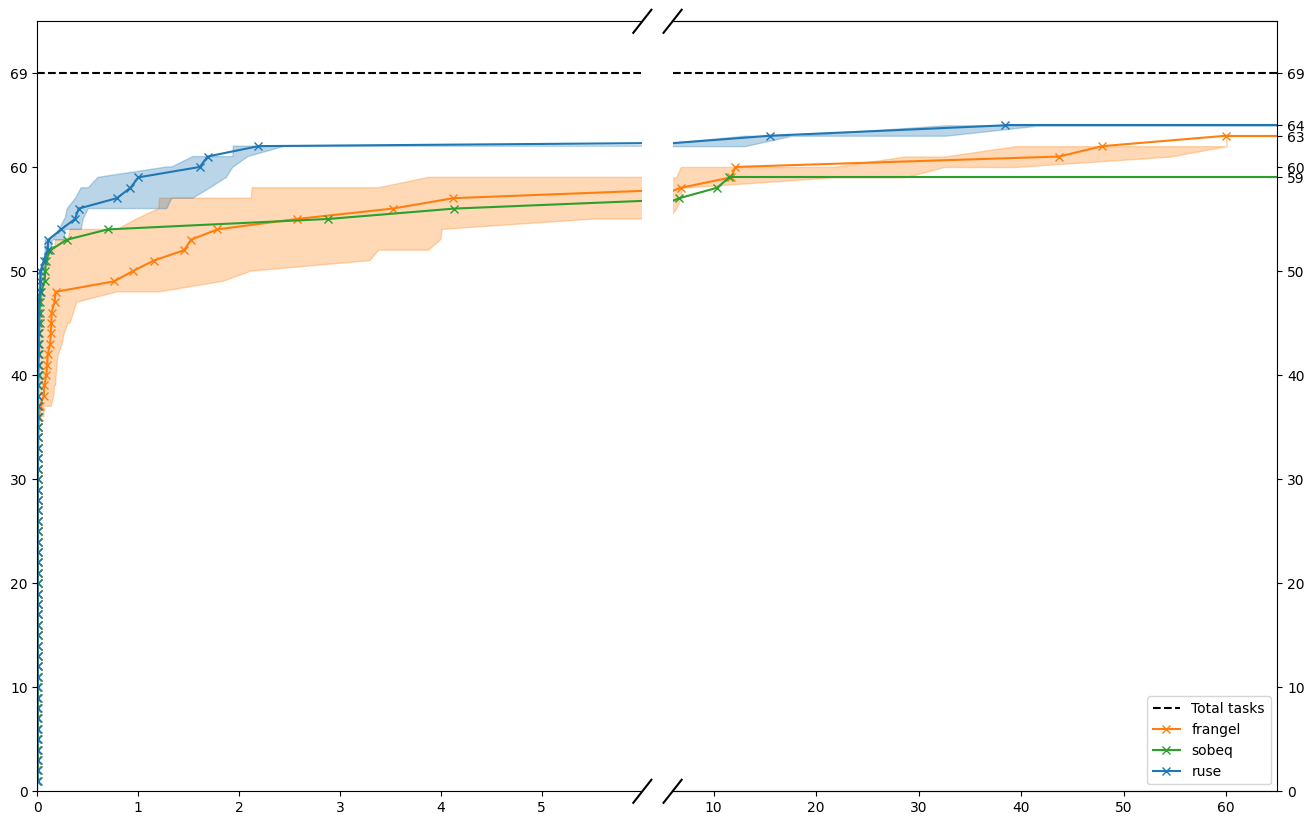

In [19]:
colors = {
    "frangel": "tab:orange",
    "sobeq": "tab:green",
    "ruse": "tab:blue",
    "frangel_min": ("tab:orange", 0.3),
    "frangel_max": ("tab:orange", 0.3)
}

primitive_solved_tasks = {"frangel": frangel_solved_tasks,
                          "sobeq": sobeq_solved_tasks, 
                          "ruse": ruse_primitive_solved_tasks}
total_primitive_tasks = len(sobeq_tasks)

plot_comparison(primitive_solved_tasks, colors, total_primitive_tasks, 
                transform_time=lambda x: x / 60,
                y=(np.arange(0, 70, 10).tolist() + [total_primitive_tasks], total_primitive_tasks+5),
                x_groups=[(0, 6, np.arange(6)), (6, 65, np.arange(10, 65, 10))],
                figsize=(16, 10))

plt.savefig("results/figures/primitive_solved_tasks.png")
save_figure_as_latex("results/figures/primitive_solved_tasks.tex")

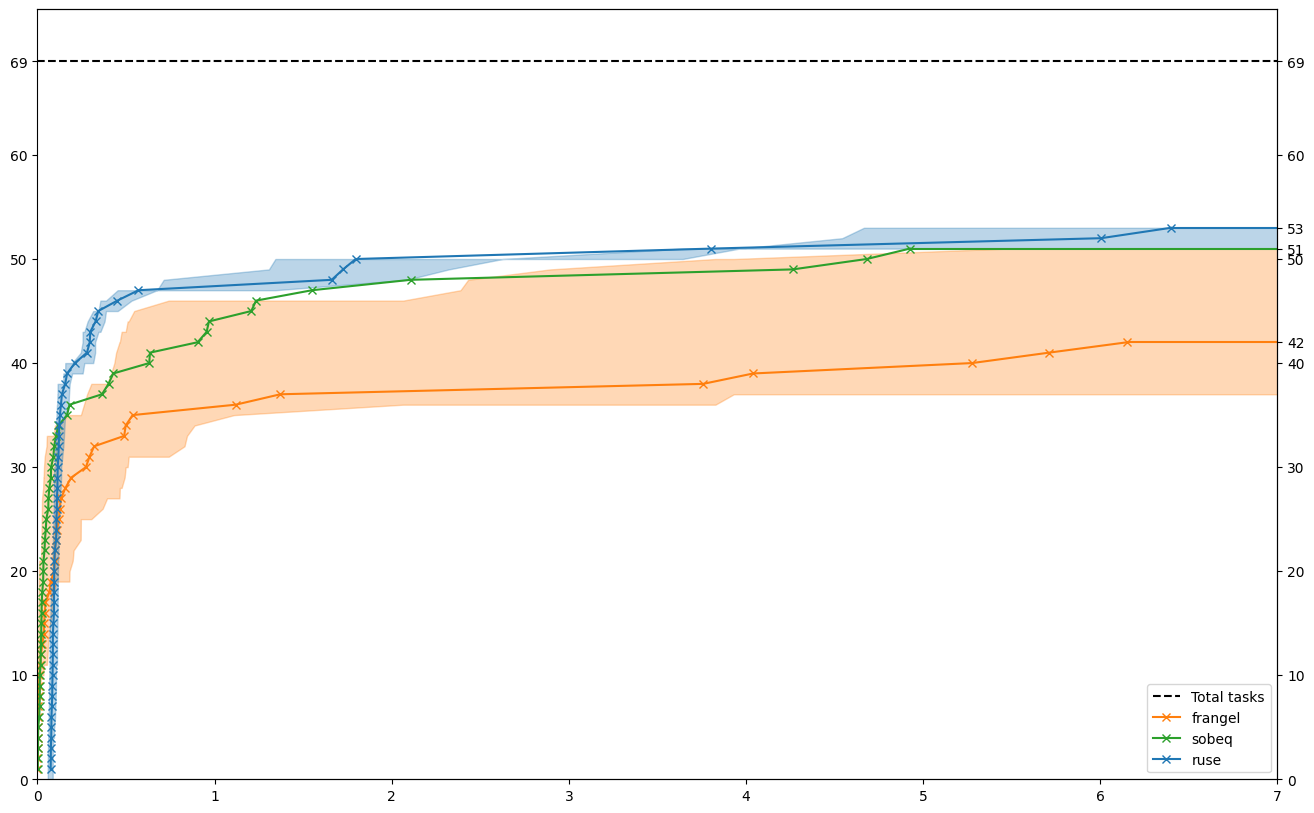

In [20]:
plot_comparison(primitive_solved_tasks, colors, total_primitive_tasks, 
                transform_time=lambda x: x[x <= 7],
                y=(np.arange(0, 70, 10).tolist() + [total_primitive_tasks], total_primitive_tasks+5),
                x_groups=[(0, 7, np.arange(8))],
                figsize=(16, 10))
plt.savefig("results/figures/primitive_solved_tasks_cutoff.png")

save_figure_as_latex("results/figures/primitive_solved_tasks_cutoff.tex")

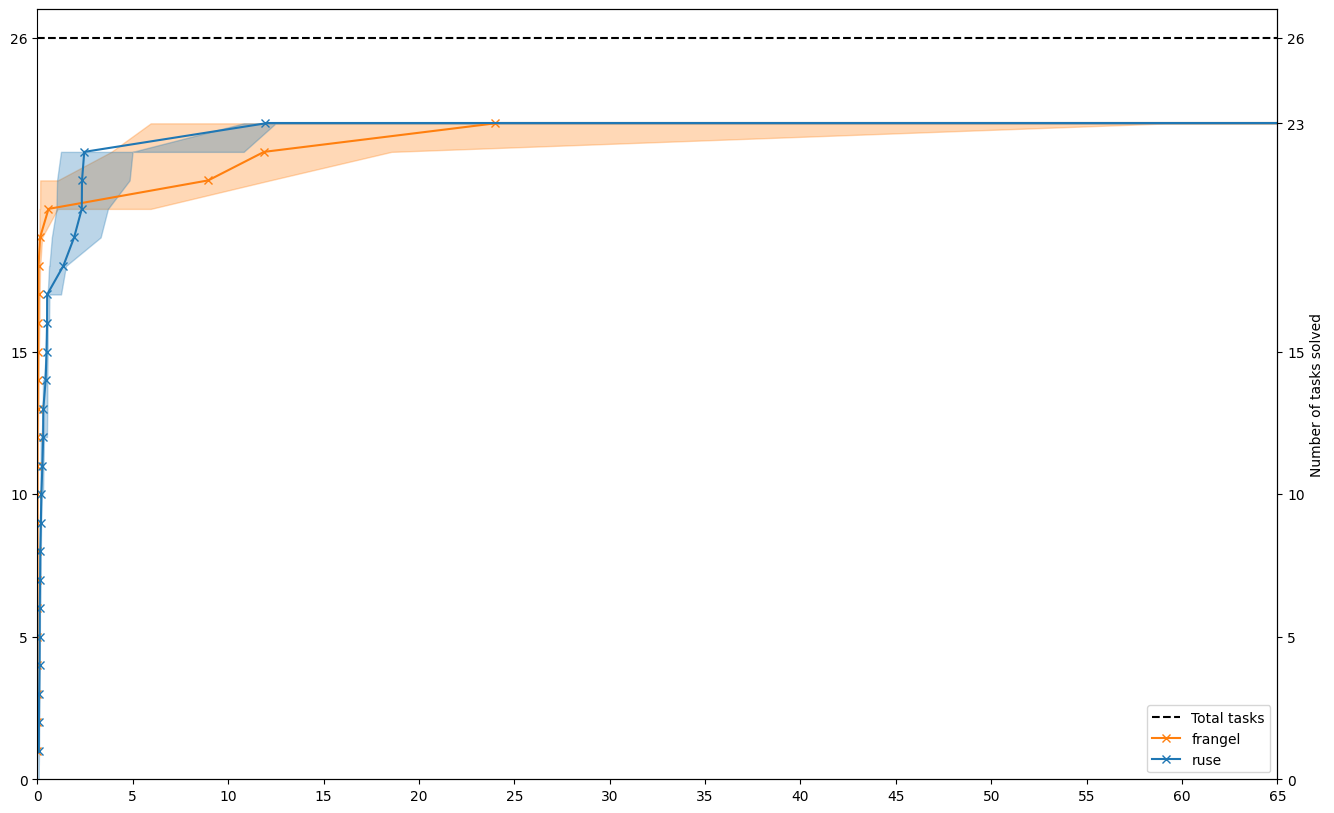

In [21]:
oop_solved_tasks = {"frangel": frangel_oop_solved_tasks,
                    "ruse": ruse_full_oop_solved_tasks}
total_oop_tasks = len(ruse_full_oop_tasks)

plot_comparison(oop_solved_tasks, colors, total_oop_tasks,  
                y=((np.arange(0, 20, 5).tolist() + [total_oop_tasks]), 27),
                x_groups=[(0, 65, np.arange(0, 66, 5))],
                figsize=(16, 10))
plt.ylabel("Number of tasks solved")
plt.xlabel("Time (seconds)")

plt.savefig("results/figures/oop_solved_tasks.png")
save_figure_as_latex("results/figures/oop_solved_tasks.tex")

### RQ2 - Can <span style="font-variant:small-caps;">Ruse</span> handle aliasing and relations between variables?

In [22]:
relations_matadata, relations_tasks = parse_results("results/ruse_experiments_relations_results", dry_run=False)
relations_tasks = group_tasks(relations_tasks)
display_df(relations_tasks[["name", "expected"]])

,name,expected
0,ArrayCounter-mustmut_aliasing_0,['count[index]++; count']
1,ArrayCounter-mustmut_aliasing_1,['count[index]++; count']
2,ArrayCounter-mustmut_aliasing_2,['count[index]++; count']
3,ArrayCounter-mustmut_aliasing_3,['count[index]++; count']
4,ArrayCounter-mustmut_aliasing_4,['count[index]++; count']
5,ArraySwap_aliasing_0,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"
6,ArraySwap_aliasing_1,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"
7,ArraySwap_aliasing_2,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"
8,ArraySwap_aliasing_3,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"
9,ArraySwap_aliasing_4,"['arr.push(arr.splice(i, 1)[0])', 'arr.push(arr.splice(i,1)[0])']"


In [23]:
pure_graph = relations_tasks[relations_tasks["name"].isin(["graph", "graph_one_way_connected", "graph_cycle"])].copy()
mut_graph = relations_tasks[relations_tasks["name"].isin(["mut_graph", "mut_graph_one_way_connected", "mut_graph_cycle"])].copy()
mut_min_ops_graph = relations_tasks[relations_tasks["name"].isin(["mut_min_ops_graph", "mut_min_ops_graph_one_way_connected", "mut_min_ops_graph_cycle"])].copy()

aliasing_task_names = relations_tasks[relations_tasks["name"].str.endswith("aliasing_0")]["name"]
aliasing_tasks = []
for name in aliasing_task_names:
    base_name = name[:name.find("_aliasing_0")]
    aliasing_tasks.append(relations_tasks[relations_tasks["name"].isin([
        f"{base_name}_aliasing_0",
        f"{base_name}_aliasing_1",
        f"{base_name}_aliasing_2",
        f"{base_name}_aliasing_3",
        f"{base_name}_aliasing_4",
    ])].reset_index())

def get_bar_name_for_graph_task(task_name):
    suffix = task_name[task_name.find("graph")+6:]
    if suffix == "":
        return "no relation"
    elif suffix == "one_way_connected":
        return "one way connected"
    elif suffix == "cycle":
        return "cycle"
    else:
        raise ValueError(f"Unknown graph task suffix: {suffix}")

def bar_names_order(names: pd.Series):
    return names.apply(lambda name: 0 if name == "no relation" else 1 if name == "one way connected" else 2)

pure_graph["name"] = pure_graph["name"].apply(get_bar_name_for_graph_task)
mut_graph["name"] = mut_graph["name"].apply(get_bar_name_for_graph_task)
mut_min_ops_graph["name"] = mut_min_ops_graph["name"].apply(get_bar_name_for_graph_task)

pure_graph.sort_values(by="name", key=bar_names_order, inplace=True)
mut_graph.sort_values(by="name", key=bar_names_order, inplace=True)
mut_min_ops_graph.sort_values(by="name", key=bar_names_order, inplace=True)

def plot_bar_chart(df, only_one = None):
    if only_one:
        fig = plt.figure(figsize=(16, 8))
    else:
        fig, ax = plt.subplots(1, 4, figsize=(16, 8))

    names = df["name"]
    
    if only_one == "iterations":
        plt.bar(names, df["iterations"].apply(lambda x: len(x)), color="C1")
        plt.title("Iterations")
        plt.locator_params(axis='y', integer=True)
    elif only_one == "bank_size":
        plt.bar(names, df["bank_size"], color="C2")
        plt.title("Bank Size")
        plt.locator_params(axis='y', integer=True)
    elif only_one == "found_context_count":
        plt.bar(names, df["found_context"], color="C3")
        plt.title("Found Context Count")
        plt.locator_params(axis='y', integer=True)
    else:
        ax[0].bar(names, df["iterations"].apply(lambda x: len(x)), color="C1")
        ax[0].title.set_text("Iterations")
        ax[0].locator_params(axis='y', integer=True)

        ax[1].bar(names, df["bank_size"], color="C2")
        ax[1].title.set_text("Bank Size")
        ax[1].locator_params(axis='y', integer=True)

        ax[2].bar(names, df["found_context"], color="C3")
        ax[2].title.set_text("Found Context Count")
        ax[2].locator_params(axis='y', integer=True)

        ax[3].bar(names, df["total_time"], color="C4")
        ax[3].title.set_text("Total Time Count")
        ax[3].locator_params(axis='y', integer=True)

    return fig


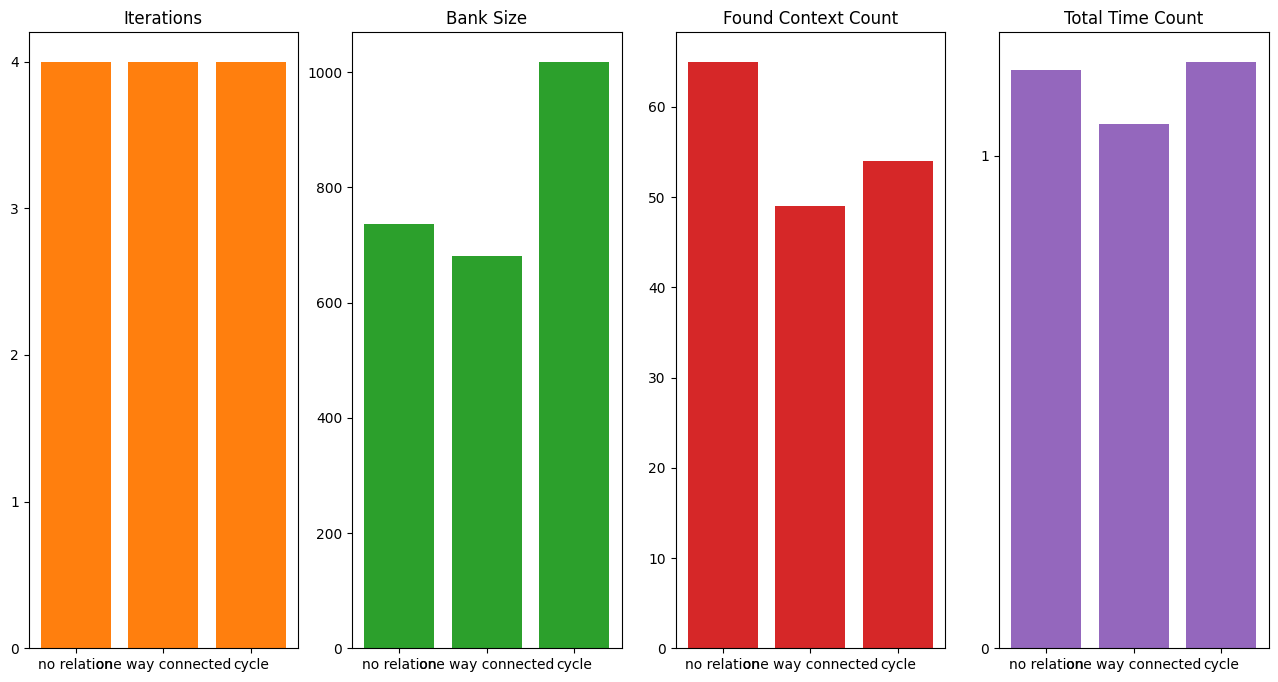

In [24]:
fig = plot_bar_chart(pure_graph)

for subplot in ["iterations", "bank_size", "found_context_count"]:
    fig = plot_bar_chart(pure_graph, subplot)
    save_figure_as_latex(f"results/figures/pure_graph_{subplot}.tex", figure=fig)
    plt.close(fig)

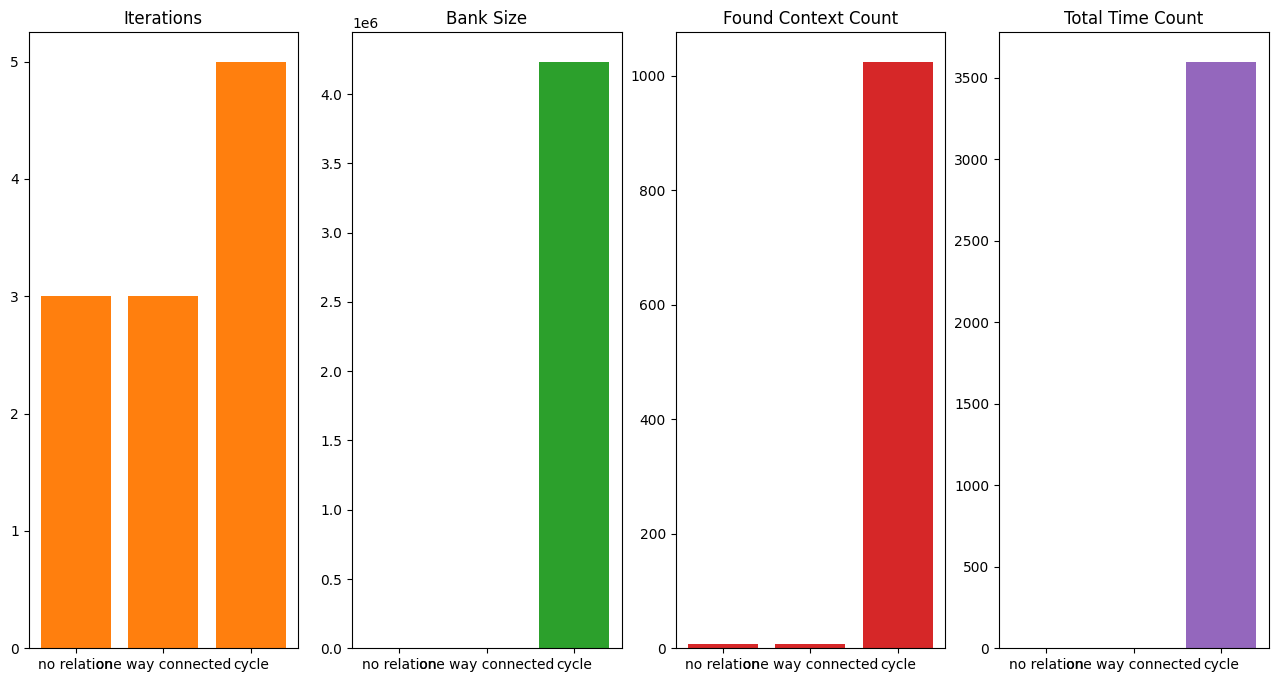

In [25]:
plot_bar_chart(mut_graph)
for subplot in ["iterations", "bank_size", "found_context_count"]:
    fig = plot_bar_chart(mut_graph, subplot)
    save_figure_as_latex(f"results/figures/mut_graph_{subplot}.tex", figure=fig)
    plt.close(fig)

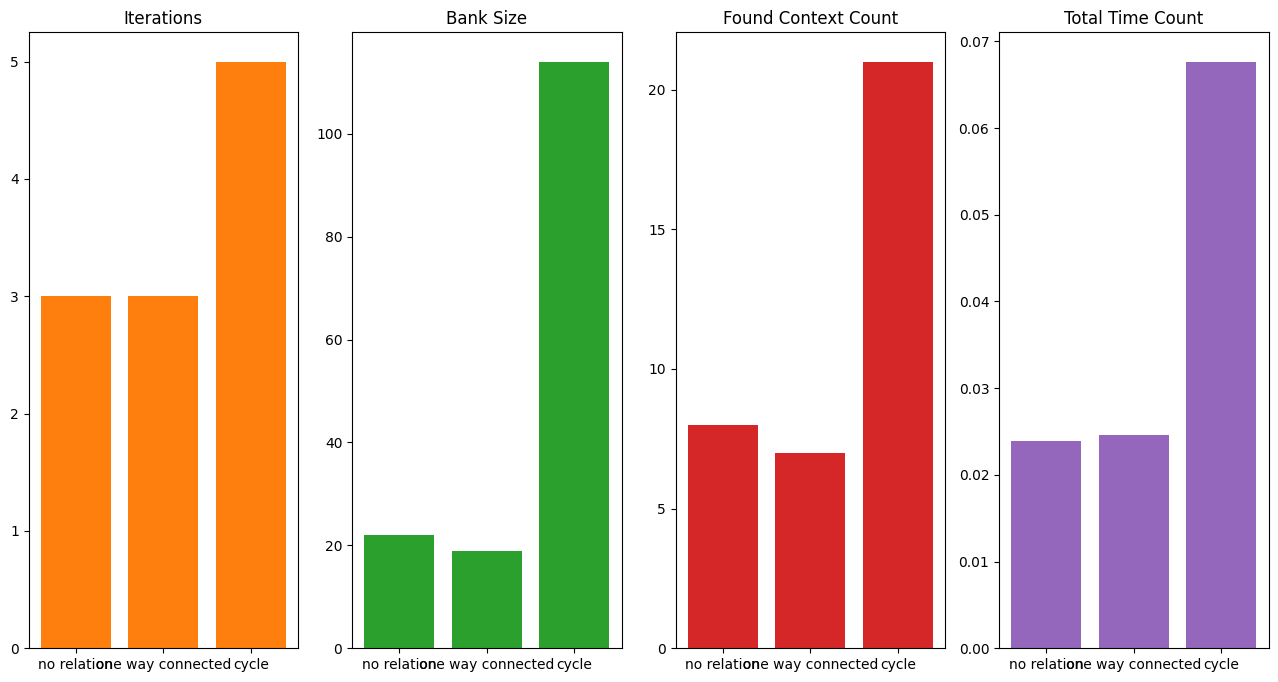

In [26]:
plot_bar_chart(mut_min_ops_graph)
for subplot in ["iterations", "bank_size", "found_context_count"]:
    fig = plot_bar_chart(mut_min_ops_graph, subplot)
    save_figure_as_latex(f"results/figures/mut_min_ops_graph_{subplot}.tex", figure=fig)
    plt.close(fig)

In [27]:
display_df(pd.concat(aliasing_tasks).reset_index()[["name", "bank_size", "found"]])

,name,bank_size,found
0,ArrayCounter-mustmut_aliasing_0,380311.000000,"{'++count[index], count'}"
1,ArrayCounter-mustmut_aliasing_1,380311.000000,"{'++count[index], count'}"
2,ArrayCounter-mustmut_aliasing_2,380311.000000,"{'++count[index], count'}"
3,ArrayCounter-mustmut_aliasing_3,380311.000000,"{'++count[index], count'}"
4,ArrayCounter-mustmut_aliasing_4,380311.000000,"{'++count[index], count'}"
5,ArraySwap_aliasing_0,539125.000000,"{'arr.push(arr.splice(i, 1).pop())'}"
6,ArraySwap_aliasing_1,539125.000000,"{'arr.push(arr.splice(i, 1).pop())'}"
7,ArraySwap_aliasing_2,539125.000000,"{'arr.push(arr.splice(i, 1).pop())'}"
8,ArraySwap_aliasing_3,539125.000000,"{'arr.push(arr.splice(i, 1).pop())'}"
9,ArraySwap_aliasing_4,539125.000000,"{'arr.push(arr.splice(i, 1).pop())'}"


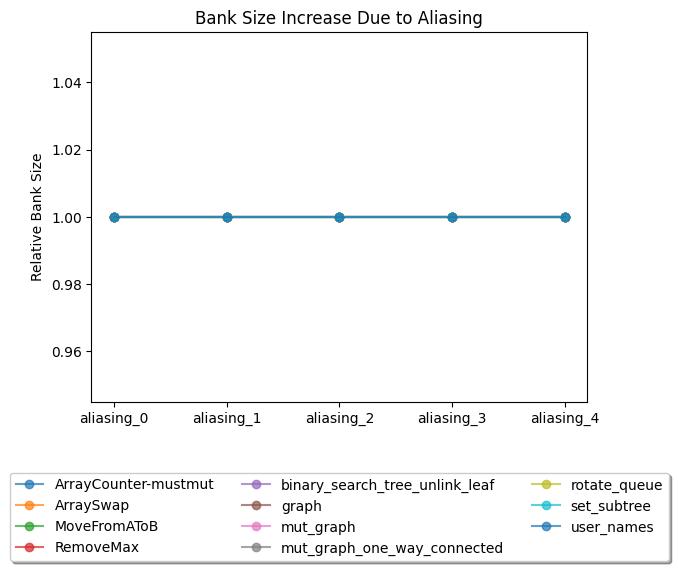

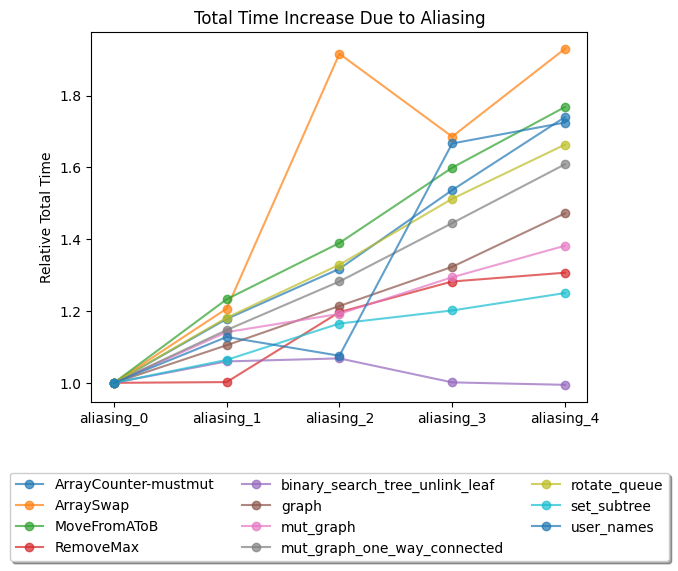

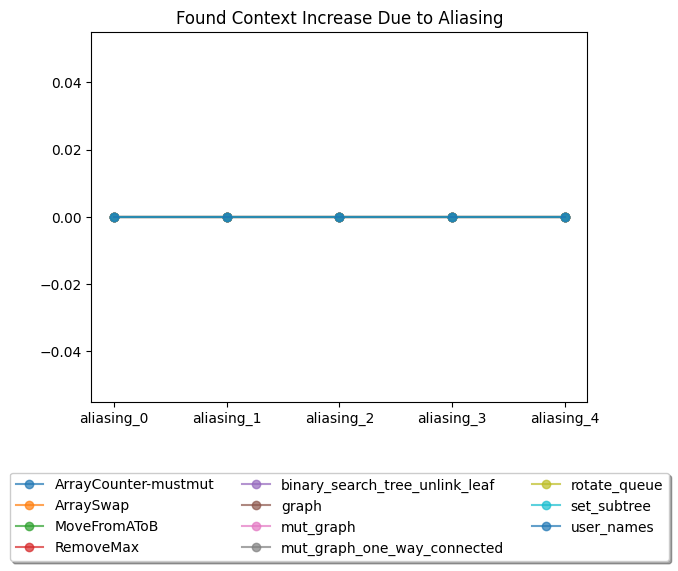

In [37]:
def export_legend(legend, filename="legend.png"):
    fig  = legend.figure
    fig.canvas.draw()
    bbox  = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).expanded(1.05, 1.1)
    fig.savefig(filename, dpi="figure", bbox_inches=bbox)

plt.figure()
for i, tasks in enumerate(aliasing_tasks):
    stripped_name = tasks["name"].apply(lambda x: x[x.find("aliasing_"):])
    base_name = tasks["name"].iloc[0][:tasks["name"].iloc[0].find("_aliasing_0")]
    plt.plot(stripped_name, tasks["bank_size"]/tasks["bank_size"].iloc[0], marker="o", label=base_name, alpha=0.7)
plt.ylabel("Relative Bank Size")
plt.title("Bank Size Increase Due to Aliasing")
legend = plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=3, fancybox=True, shadow=True)
save_figure_as_latex(f"results/figures/aliasing_bank_size.tex")
export_legend(legend, "results/figures/aliasing_legend.png")
plt.figure()
for tasks in aliasing_tasks:
    stripped_name = tasks["name"].apply(lambda x: x[x.find("aliasing_"):])
    base_name = tasks["name"].iloc[0][:tasks["name"].iloc[0].find("_aliasing_0")]
    plt.plot(stripped_name, tasks["total_time"]/tasks["total_time"].iloc[0], marker="o", label=base_name, alpha=0.7)
plt.ylabel("Relative Total Time")
plt.title("Total Time Increase Due to Aliasing")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=3, fancybox=True, shadow=True)
save_figure_as_latex(f"results/figures/aliasing_total_time.tex")
plt.figure()
for i, tasks in enumerate(aliasing_tasks):
    stripped_name = tasks["name"].apply(lambda x: x[x.find("aliasing_"):])
    base_name = tasks["name"].iloc[0][:tasks["name"].iloc[0].find("_aliasing_0")]
    plt.plot(stripped_name, tasks["found_context"] - (tasks["found_context"].iloc[0]), marker="o", label=base_name, alpha=0.7)
plt.title("Found Context Increase Due to Aliasing")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=3, fancybox=True, shadow=True)
save_figure_as_latex(f"results/figures/aliasing_found_context.tex")

### RQ3 - <span style="font-variant:small-caps;">Ruse</span> Embedding overhead

In [29]:
def read_embedding_result(result_path):
    overhead_runs = []
    metadata, overhead_tasks = parse_results(result_path, dry_run=False)
    overhead_tasks = group_tasks(overhead_tasks)
    for path in os.listdir(result_path):
        if path.endswith(".csv"):
            embedding_results = pd.read_csv(os.path.join(result_path, path))
            embedding_results["Task"] = embedding_results["Task"].apply(lambda x: x.split(".")[0])
            embedding_results = embedding_results.groupby("Task").last().reset_index()
            embedding_results["Time multiplier"] = embedding_results["Took with embedding"] / (embedding_results["Took without embedding"] * overhead_tasks["examples_count"])
            embedding_results["skipped"] = embedding_results["Total programs"] - embedding_results["Valid sequences"]
            embedding_results["skipped%"] = (embedding_results["skipped"] / embedding_results["Total programs"] * 100)
            overhead_runs.append(embedding_results)

            assert((overhead_tasks["name"] == embedding_results["Task"]).all())

    def get_program_mil(row):
        return row.mean() / 1_000_000

    overhead = pd.concat(overhead_runs, ignore_index=True).groupby("Task").agg(
        bank_size = ("Bank size", "mean"),
        total_programs = ("Total programs", get_program_mil),
        valid_sequences = ("Valid sequences", get_program_mil),
        took_without_embedding = ("Took without embedding", "mean"),
        took_with_embedding = ("Took with embedding", "mean"),
        time_multiplier = ("Time multiplier", "mean"),
        time_multiplier_std = ("Time multiplier", "std"),
        skipped = ("skipped", get_program_mil),
        skipped_perc = ("skipped%", "mean"),
        skipped_perc_std = ("skipped%", "std"),
    ).reset_index()
    overhead.rename(columns={
        "total_programs": "Total Programs (M)",
        "valid_sequences": "Valid Tuples (M)"
    }, inplace=True)

    def get_var_mean_node_count(var):
        return np.mean([x["node_count"] for x in var["partial_ctx_graph"]], dtype=int)

    overhead["Task"] = overhead["Task"].apply(lambda x: x.split(".")[0])
    overhead["examples_count"] = overhead_tasks["examples_count"]
    overhead["var_count"] = overhead_tasks["var_count"]
    overhead["nodes"] = overhead_tasks["start_context"].apply(lambda x: np.mean([g["node_count"] for g in x]).astype("int"))
    overhead["edges"] = overhead_tasks["start_context"].apply(lambda x: np.mean([g["edge_count"] for g in x]).astype("int"))
    overhead["nodes_per_var"] = overhead_tasks["start_context_variables"].apply(lambda x: np.sort([get_var_mean_node_count(var) for var in x]))
    overhead["oop_category"] = overhead_tasks["oop_category"]

    return overhead

def save_embedding_as_latex_table(df: pd.DataFrame, filename: str, columns_map: list[tuple[str, str]]):
    columns = ["Task"] + [x[0] for x in columns_map]
    headers = ["Task"] + [x[1] for x in columns_map]
    column_types = ["l"] + ["c"] * (len(columns_map))
    df = df[columns].copy()
    df.columns = headers
    s = df.style.format(precision=2, escape="latex").hide(axis=0)
    # s.relabel_index(headers) 

    latex = s.to_latex(column_format=''.join(column_types))
    print(latex)
    # latex = ""
    # latex += f"\\begin{{tabular}}{{{''.join(column_types)}}}\n"
    
    # latex += '\t\\hline\n'
    # latex += "\t" + " & ".join([f"\\textbf{{{h}}}" for h in headers])
    # latex += " \\\\\n"
    # latex += '\t\\hline\n'

    # for _, row in df.iterrows():
    #     latex += "\t" + " & ".join([f"{cell}" for cell in row])
    #     latex += " \\\\\n"
    # latex += "\\hline\n"
    # latex += "\\end{{tabular}}\n"
    with open(filename, "w") as f:
        f.write(latex)


,Task,var_count,examples_count,nodes,edges,nodes_per_var,skipped_perc,time_multiplier,Total Programs (M),Valid Tuples (M),took_without_embedding,took_with_embedding
9,graph,3,1,12,9,[4 4 4],31.992773,450.475893,14.656791,9.967831,0.080000,35.440000
11,graph_one_way_connected,3,1,8,7,[4 6 8],48.063630,360.934091,12.933352,6.717283,0.087500,30.450000
10,graph_cycle,3,1,6,6,[6 6 6],87.299542,208.236247,36.757164,4.668367,0.202500,41.942500
15,user_names_aliasing,4,2,2,0,[1 1 1 1],6.147685,145.859090,2573.182664,2414.991287,6.062500,1763.185000
16,user_names_connected,3,2,4,3,[1 1 4],6.161901,125.495485,2552.100737,2394.842731,6.505000,1611.735000
17,user_names_simple,2,2,2,0,[1 1],6.156009,117.128763,2547.912219,2391.061694,6.832500,1579.992500
14,user_names,3,2,6,3,[1 1 4],6.146896,113.260883,2549.304533,2392.601364,6.857500,1534.212500
6,abcd,4,1,0,0,[0 0 0 0],0.000000,48.250000,0.789279,0.789279,0.010000,0.482500
5,abc,3,1,0,0,[0 0 0],0.000000,33.000000,0.390999,0.390999,0.010000,0.330000
0,FirstAndLast,1,3,1,0,[1],70.173030,29.688365,2670.168226,796.419615,7.582500,672.265000


\begin{tabular}{lcccccc}
Task & $\left|\Phi\right|$ & $\left|\mathcal{V}\right|$ & $\left|S_V\right|$ & Skipped (\%) & $\mathcal{T}$ & $\sigma_{\mathcal{T}}$ \\
graph & 1 & 3 & 12 & 31.99 & 450.48 & 56.78 \\
graph\_one\_way\_connected & 1 & 3 & 8 & 48.06 & 360.93 & 76.50 \\
graph\_cycle & 1 & 3 & 6 & 87.30 & 208.24 & 15.65 \\
user\_names\_aliasing & 2 & 4 & 2 & 6.15 & 145.86 & 15.92 \\
user\_names\_connected & 2 & 3 & 4 & 6.16 & 125.50 & 21.01 \\
user\_names\_simple & 2 & 2 & 2 & 6.16 & 117.13 & 16.57 \\
user\_names & 2 & 3 & 6 & 6.15 & 113.26 & 13.35 \\
abcd & 1 & 4 & 0 & 0.00 & 48.25 & 22.43 \\
abc & 1 & 3 & 0 & 0.00 & 33.00 & 9.20 \\
FirstAndLast & 3 & 1 & 1 & 70.17 & 29.69 & 2.81 \\
IsAllPositive & 3 & 1 & 1 & 77.39 & 25.12 & 3.07 \\
set\_subtree & 1 & 2 & 6 & 38.98 & 22.88 & 4.53 \\
MoveFromAToB & 2 & 2 & 2 & 39.14 & 6.25 & 0.29 \\
binary\_search\_tree\_unlink\_leaf & 1 & 1 & 2 & 17.26 & 6.13 & 1.75 \\
NegativeIndex & 2 & 2 & 0 & 0.00 & 5.38 & 0.25 \\
seq & 2 & 2 & 1 & 29.45 & 3.7

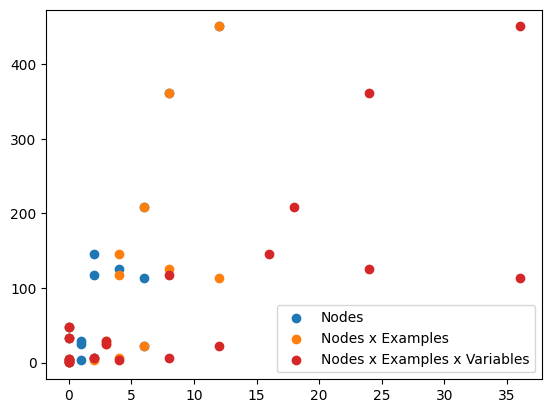

In [30]:
wide_overhead = read_embedding_result("results/ruse_experiments_wide_embedding_results")
display_df(wide_overhead.sort_values(by="time_multiplier", ascending=False)[["Task", "var_count", "examples_count", "nodes", "edges", "nodes_per_var", "skipped_perc", "time_multiplier", "Total Programs (M)", "Valid Tuples (M)", "took_without_embedding", "took_with_embedding"]])
save_embedding_as_latex_table(wide_overhead.sort_values(by="time_multiplier", ascending=False), "results/figures/wide_embedding_overhead_table.tex", [
    ("examples_count" ,"$\\left|\Phi\\right|$"),
    ("var_count" ,"$\\left|\mathcal{V}\\right|$"),
    ("nodes" ,"$\\left|S_V\\right|$"),
    ("skipped_perc" ,"Skipped (\\%)"),
    ("time_multiplier" ,"$\\mathcal{T}$"),
    ("time_multiplier_std" ,"$\sigma_{\\mathcal{T}}$")
])

wide_overhead.sort_values(by="time_multiplier", ascending=False)[["Task", "examples_count", "var_count", "nodes", "skipped_perc", "skipped_perc_std", "time_multiplier", "time_multiplier_std"]].to_latex(index=False, float_format="%.2f", buf="results/figures/embedding_overhead.tex")

full_oop_overhead = wide_overhead[wide_overhead["oop_category"] != "Primitive"]
primitive_overhead = wide_overhead[wide_overhead["oop_category"] == "Primitive"]
print(len(full_oop_overhead), len(primitive_overhead))

# plt.scatter(full_oop_overhead["time_multiplier"], full_oop_overhead["Skipped%"], color="C0")
# plt.scatter(primitive_overhead["time_multiplier"], primitive_overhead["Skipped%"], color="C1")
plt.scatter(wide_overhead["nodes"], wide_overhead["time_multiplier"], color="C0")
plt.scatter(wide_overhead["nodes"] * wide_overhead["examples_count"], wide_overhead["time_multiplier"], color="C1")
plt.scatter(wide_overhead["nodes"] * wide_overhead["examples_count"] * wide_overhead["var_count"], wide_overhead["time_multiplier"], color="C3")
# plt.scatter(wide_overhead["total_programs"], wide_overhead["took_without_embedding"], color="C3")
plt.legend([
    "Nodes",
    "Nodes x Examples",
    "Nodes x Examples x Variables",
])

\begin{tabular}{lcccccc}
Task & $\left|\Phi\right|$ & $\left|\mathcal{V}\right|$ & $\left|S_V\right|$ & Skipped (\%) & $\mathcal{T}$ & $\sigma_{\mathcal{T}}$ \\
graph\_one\_way\_connected\_1\_3 & 1 & 3 & 18 & 47.94 & 473.39 & 97.46 \\
graph\_1\_2 & 1 & 3 & 18 & 31.95 & 432.99 & 84.82 \\
graph\_1\_3 & 1 & 3 & 18 & 31.82 & 428.42 & 37.19 \\
graph\_one\_way\_connected\_1\_2 & 1 & 3 & 18 & 48.09 & 397.98 & 19.08 \\
graph\_one\_way\_connected\_1\_1 & 1 & 3 & 12 & 47.92 & 385.79 & 110.44 \\
graph\_cycle\_1\_3 & 1 & 3 & 18 & 87.36 & 361.07 & 14.06 \\
graph\_cycle\_1\_2 & 1 & 3 & 18 & 87.37 & 316.92 & 27.10 \\
graph\_cycle\_1\_1 & 1 & 3 & 12 & 87.35 & 304.51 & 24.52 \\
graph\_1\_1 & 1 & 3 & 12 & 31.95 & 272.28 & 11.16 \\
graph\_cycle\_1 & 1 & 3 & 6 & 87.33 & 268.10 & 58.77 \\
graph\_one\_way\_connected\_2 & 2 & 3 & 6 & 51.63 & 231.34 & 24.02 \\
graph\_one\_way\_connected\_3 & 3 & 3 & 6 & 51.31 & 227.94 & 57.50 \\
graph\_one\_way\_connected\_1 & 1 & 3 & 6 & 49.87 & 216.95 & 12.68 \\
graph\_cycl

,Task,var_count,examples_count,nodes,edges,nodes_per_var,skipped_perc,time_multiplier,Total Programs (M),Valid Tuples (M),took_without_embedding,took_with_embedding
2,graph_1_2,3,1,18,15,[6 6 6],31.945206,432.991071,13.905286,9.463247,0.097500,41.087500
3,graph_1_3,3,1,18,15,[6 6 6],31.818238,428.418182,14.123876,9.630021,0.105000,44.972500
1,graph_1_1,3,1,12,9,[4 4 4],31.946953,272.278409,13.905646,9.463339,0.115000,31.297500
5,graph_3,3,3,6,3,[2 2 2],35.722092,159.341667,13.348322,8.580108,0.087500,39.942500
0,graph_1,3,1,6,3,[2 2 2],33.535054,152.658333,10.713033,7.120508,0.087500,12.880000
4,graph_2,3,2,6,3,[2 2 2],35.914931,130.255682,13.055616,8.366961,0.107500,27.915000


,Task,var_count,examples_count,nodes,edges,nodes_per_var,skipped_perc,time_multiplier,Total Programs (M),Valid Tuples (M),took_without_embedding,took_with_embedding
15,graph_one_way_connected_1_3,3,1,18,17,[ 6 12 18],47.938692,473.386364,12.851517,6.690858,0.100000,45.922500
14,graph_one_way_connected_1_2,3,1,18,17,[ 6 12 18],48.092343,397.979545,12.811872,6.651558,0.107500,42.760000
13,graph_one_way_connected_1_1,3,1,12,11,[ 4 8 12],47.916619,385.788961,12.689179,6.609138,0.090000,32.842500
16,graph_one_way_connected_2,3,2,6,5,[2 4 6],51.627749,231.338068,15.343169,7.421776,0.107500,49.322500
17,graph_one_way_connected_3,3,3,6,5,[2 4 6],51.305065,227.937500,16.002456,7.792760,0.110000,72.670000
12,graph_one_way_connected_1,3,1,6,5,[2 4 6],49.872533,216.950000,11.773554,5.903383,0.100000,21.695000


,Task,var_count,examples_count,nodes,edges,nodes_per_var,skipped_perc,time_multiplier,Total Programs (M),Valid Tuples (M),took_without_embedding,took_with_embedding
9,graph_cycle_1_3,3,1,18,18,[18 18 18],87.363525,361.070782,36.674080,4.634311,0.190000,68.490000
8,graph_cycle_1_2,3,1,18,18,[18 18 18],87.366797,316.922386,36.674080,4.633111,0.180000,56.955000
7,graph_cycle_1_1,3,1,12,12,[12 12 12],87.354846,304.509921,36.674080,4.637494,0.160000,48.307500
6,graph_cycle_1,3,1,6,6,[6 6 6],87.334227,268.097961,36.840247,4.666184,0.162500,42.195000
10,graph_cycle_2,3,2,6,6,[6 6 6],87.908776,180.438296,51.068836,6.174941,0.215000,76.525000
11,graph_cycle_3,3,3,6,6,[6 6 6],87.627631,150.334943,53.481285,6.616958,0.225000,98.672500


0    12.8800
4    27.9150
5    39.9425
Name: took_with_embedding, dtype: float64
12    21.6950
16    49.3225
17    72.6700
Name: took_with_embedding, dtype: float64
6     42.1950
10    76.5250
11    98.6725
Name: took_with_embedding, dtype: float64
[13.53125 -0.15   ] [25.4875     -3.07916667] [28.23875    15.98666667]


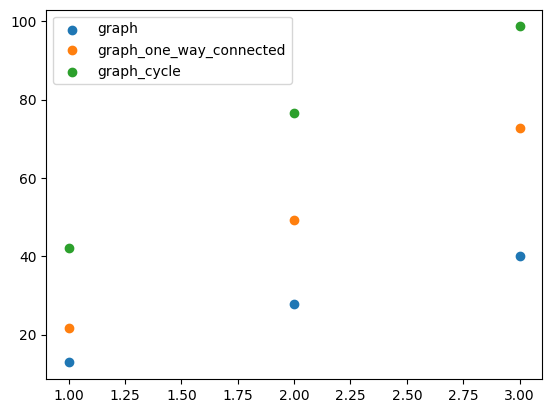

In [31]:
graph_overhead = read_embedding_result("results/ruse_experiments_graph_embedding_results")
graph_overhead.sort_values(by="time_multiplier", ascending=False)[["Task", "examples_count", "var_count", "nodes", "skipped_perc", "skipped_perc_std", "time_multiplier", "time_multiplier_std"]].to_latex(index=False, float_format="%.2f", buf="results/figures/graph_embedding_overhead.tex")
save_embedding_as_latex_table(graph_overhead.sort_values(by="time_multiplier", ascending=False), "results/figures/graph_embedding_overhead_table.tex", [
    ("examples_count" ,"$\\left|\Phi\\right|$"),
    ("var_count" ,"$\\left|\mathcal{V}\\right|$"),
    ("nodes" ,"$\\left|S_V\\right|$"),
    ("skipped_perc" ,"Skipped (\\%)"),
    ("time_multiplier" ,"$\\mathcal{T}$"),
    ("time_multiplier_std" ,"$\sigma_{\\mathcal{T}}$")
])


display_df(graph_overhead[graph_overhead["Task"].str.len() < 13].sort_values(by="time_multiplier", ascending=False)[["Task", "var_count", "examples_count", "nodes", "edges", "nodes_per_var", "skipped_perc", "time_multiplier", "Total Programs (M)", "Valid Tuples (M)", "took_without_embedding", "took_with_embedding"]])
display_df(graph_overhead[graph_overhead["Task"].str.startswith('graph_one_way_connected')].sort_values(by="time_multiplier", ascending=False)[["Task", "var_count", "examples_count", "nodes", "edges", "nodes_per_var", "skipped_perc", "time_multiplier", "Total Programs (M)", "Valid Tuples (M)", "took_without_embedding", "took_with_embedding"]])
display_df(graph_overhead[graph_overhead["Task"].str.startswith('graph_cycle')].sort_values(by="time_multiplier", ascending=False)[["Task", "var_count", "examples_count", "nodes", "edges", "nodes_per_var", "skipped_perc", "time_multiplier", "Total Programs (M)", "Valid Tuples (M)", "took_without_embedding", "took_with_embedding"]])

examples = ['graph_1', 'graph_2', 'graph_3']
examples_one_way = ['graph_one_way_connected_1', 'graph_one_way_connected_2', 'graph_one_way_connected_3']
examples_cycle = ['graph_cycle_1', 'graph_cycle_2', 'graph_cycle_3']

examples_compare = graph_overhead[graph_overhead["Task"].isin(examples)].sort_values(by="examples_count")
examples_one_way_compare = graph_overhead[graph_overhead["Task"].isin(examples_one_way)].sort_values(by="examples_count")
examples_cycle_compare = graph_overhead[graph_overhead["Task"].isin(examples_cycle)].sort_values(by="examples_count")

plt.scatter(examples_compare["examples_count"], examples_compare["took_with_embedding"], color="C0")
plt.scatter(examples_one_way_compare["examples_count"], examples_one_way_compare["took_with_embedding"], color="C1")
plt.scatter(examples_cycle_compare["examples_count"], examples_cycle_compare["took_with_embedding"], color="C2")

print(examples_compare["took_with_embedding"])
print(examples_one_way_compare["took_with_embedding"])
print(examples_cycle_compare["took_with_embedding"])
coeff = np.polyfit([1, 2, 3], examples_compare["took_with_embedding"], 1)
coeff_one_way = np.polyfit([1, 2, 3], examples_one_way_compare["took_with_embedding"], 1)
coeff_cycle = np.polyfit([1, 2, 3], examples_cycle_compare["took_with_embedding"], 1)
print(coeff, coeff_one_way, coeff_cycle)

plt.legend([
    "graph",
    "graph_one_way_connected",
    "graph_cycle",
])

In [32]:
# wide_overhead = read_embedding_result("results/primitive_overhead_results")
# display_df(wide_overhead.sort_values(by="time_multiplier", ascending=False)[["Task", "var_count", "examples_count", "nodes", "edges", "nodes_per_var", "skipped_perc", "time_multiplier", "Total Programs (M)", "Valid Tuples (M)", "took_without_embedding", "took_with_embedding"]])
